
## Task 3: Clustering – Customer Segmentation for E-Commerce

In this task, an unsupervised learning approach (K-Means clustering) is used to segment customers based on their purchasing behavior. Features such as spending amount, order frequency, and product categories are used to create meaningful groups like loyal buyers and bargain hunters. The optimal number of clusters is determined using the Elbow Method and Silhouette Score, and business insights are generated for targeted marketing strategies.
.



In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
# 1. Dataset Selection & Loading
df = pd.read_csv('Ecommerce Customer Behavior Dataset.csv')

In [3]:
# 2. Preprocessing
# We focus on the RFM model logic: Recency, Frequency, and Monetary value.
# Selecting relevant features for behavioral clustering
features = ['Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Returns_Rate']
X = df[features].copy()

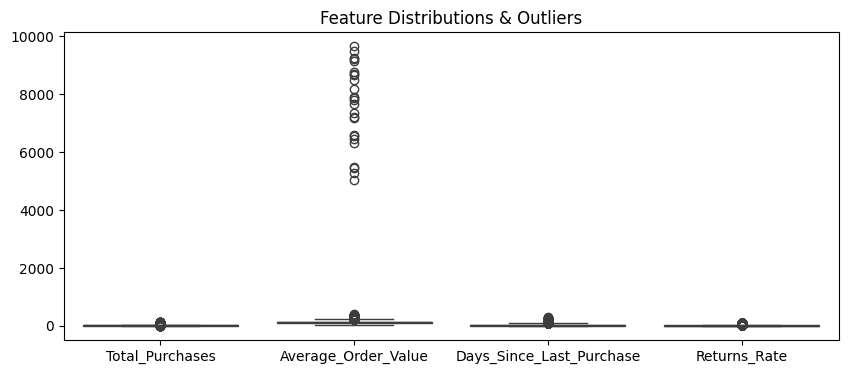

In [4]:
# 3. EDA (Exploratory Data Analysis)
# Visualizing distributions to check for outliers
plt.figure(figsize=(10, 4))
sns.boxplot(data=X)
plt.title("Feature Distributions & Outliers")
plt.show()

In [5]:
# 4. Feature Engineering
# Handling missing values with median to maintain data integrity
X = X.fillna(X.median())

In [6]:
# 5. Justification
# Feature Choice: Total_Purchases (Frequency) and Average_Order_Value (Monetary) 
# define the financial value of a customer, while Days_Since_Last_Purchase (Recency) 
# indicates engagement. Returns_Rate helps identify 'high-maintenance' customers.

# 6. Handling Class Imbalance
# Not applicable for K-Means as it is unsupervised; however, we ensure 
# scaling prevents feature dominance.

# 7. Normalization
# K-Means is distance-based, so all features must be on the same scale.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# 8. Train-Test Split
# Typically not used in clustering unless validating stability. 
# We use the full scaled dataset for segment discovery.

# 9. Model Training: Finding Optimal K (The Elbow Method)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [8]:
# 10. Evaluation (Silhouette Score)
# Assuming K=3 based on the elbow bend
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X_scaled)
score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score for K=3: {score:.3f}")

Silhouette Score for K=3: 0.291


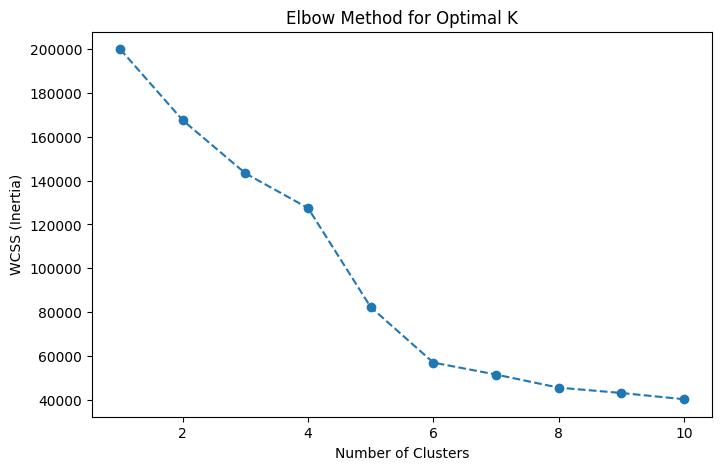

In [9]:
# 11. Results Visualization (a: Elbow Method)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.show()

In [10]:
# Train the model
km_final = KMeans(n_clusters=3, random_state=42)
clusters = km_final.fit_predict(X_scaled)

# STEP: ADD COLUMN TO DF BEFORE GROUPBY
df['Cluster'] = clusters 

# Now this will work:
cluster_summary = df.groupby('Cluster')[features].mean()
print(cluster_summary)

         Total_Purchases  Average_Order_Value  Days_Since_Last_Purchase  \
Cluster                                                                   
0              12.584149           145.235031                 83.991611   
1              20.701964           118.804481                 20.919484   
2               9.471866           119.515024                 19.060335   

         Returns_Rate  
Cluster                
0            6.481417  
1            8.165432  
2            5.990036  
